## 第一章 机器学习概览
---

* 机器学习的定义：一个计算机程序利用经验E来学习任务T，性能是P，如果针对任务T的性能P随着经验E不断增长，则成为机器学习
* 机器学习的适用：
    * 现有解决方案需要大量微调或一长串规则来解决的问题
    * 使用传统方法无法解决的复杂问题
    * 变化的环境
    * 深入了解复杂问题和大量数据

* 机器学习的类型：
    * 在训练期间是如何收到监督的。（监督学习、无监督学习、半监督学习、自我监督学习）
        * 监督学习
            * 定义：提供给包含所需解决方案的算法的训练集，称为标签
            * 典型任务：
                * 分类：指离散型任务（例如：垃圾邮件分类）
                * 回归：指连续型任务（例如：预测汽车价格）
        * 无监督学习
            * 定义：训练数据是未标记的
            * 典型任务：
                * 可视化算法（例如：检测相似访客的分组）
                * 降维（例如：将相关特征合并）
                * 异常检测（例如：检测看起来与训练集中所有实例不同的新实例）
                * 关联规则学习（挖掘大量数据并发现属性之间的关联）
        * 半监督学习
            * 定义：处理一般分已标记的数据
            * 典型任务：
                * 照片托管服务（例如：google相册的人物区分，需用户自己定义标签）
        * 自监督学习
            * 定义：从完全未标记的数据集生成完全标记的数据集
            * 典型任务：
                * 修复损坏的图像
                * 从图像中删除不想要的对象
    * 是否可以即时增量地学习。（在线学习、批量学习）
        * 批量学习
            * 定义：无法进行增量学习。必须使用所有可用的数据集进行训练。通常会占用大量的时间和计算资源，因此通常需要离线完成，即离线学习。
            * 挑战
                * 由于世界的不断发展，而模型保持不变，该现象称为模型腐烂或数据漂移。故需定期重新训练模型，但需大量计算资源
        * 在线学习
            * 定义：通过以单独的数据或小批量的小组数据方式循序地向系统提供数据实例来对系统进行增量训练。
            * 典型任务：
                * 检测股票市场的新模式
                * 含有超大数据集的任务（此时在线学习也称核外（out-of-core）学习，通常核外学习是离线完成的，但它属于增量学习）
            * 挑战
                * 数据质量与学习率不良会导致性能下降
    * 是通过简单地将数据与已知数据进行比较来工作，还是通过检测训练数据中的模式并建立预测模型来工作（基于实例的学习、基于模型的学习）
        * 基于实例的学习
            * 定义：用心学习样例，通过使用相似性度量将它们与学习到的样例（或它们的子集）进行比较来泛化到新实例
        * 基于模型的学习
            * 定义：为样例构建一个模型，然后使用该模型进行预测

* 典型的机器学习项目
    * 研究数据
    * 选择一个模型
    * 使用训练数据进行训练
    * 应用该模型对新实例进行预测（推断），希望该模型有泛化能力

---

* 机器学习的主要挑战
    * 不良模型
    * 不良数据
        * 训练数据量不足
        * 训练数据不具代表性
            * 如果样本太小，容易出现采样噪声（即非代表性数据被选中）
            * 如果样本太大，容易出现采样偏差
        * 低质量数据
        * 无关特征数据，特征工程包括
            * 特征选择（选择最有用的特征进行训练）
            * 特征提取（结合现有特征产生更有用的特征，如降维算法）
            * 收集新数据创建新特征
        * 过拟合训练数据（指模型在训练数据上表现良好，但泛化效果不佳），解决方案如下：
            * 通过选择参数较少的模型、减少训练数据中的属性数量或约束模型（称正则化）来简化模型
            * 收集更多训练数据
            * 减少训练数据中的噪声（如修复错误数据并移除异常值）
        * 欠拟合训练数据（指当模型太简单时无法学习数据的底层结构），解决方案如下：
            * 选择具有更多参数的更强大的模型
            * 为学习算法提供更好的特征（特征工程）
            * 减少对模型的约束（如减少正则化超参数）

---

* 补充知识点：
    * 迁移学习
        * 定义：将知识从一项任务转移到另一项任务
    * 强化学习
        * 定义：可观察环境，选择和执行动作，并获得正回报或负回报
        * 典型任务：
            * AlphaGo

           Country  GDP per capita (USD)  Life satisfaction
0           Russia          26456.387938                5.8
1           Greece          27287.083401                5.4
2           Turkey          28384.987785                5.5
3           Latvia          29932.493910                5.9
4          Hungary          31007.768407                5.6
5         Portugal          32181.154537                5.4
6           Poland          32238.157259                6.1
7          Estonia          35638.421351                5.7
8            Spain          36215.447591                6.3
9         Slovenia          36547.738956                5.9
10       Lithuania          36732.034744                5.9
11          Israel          38341.307570                7.2
12           Italy          38992.148381                6.0
13  United Kingdom          41627.129269                6.8
14          France          42025.617373                6.5
15     New Zealand          42404.393738

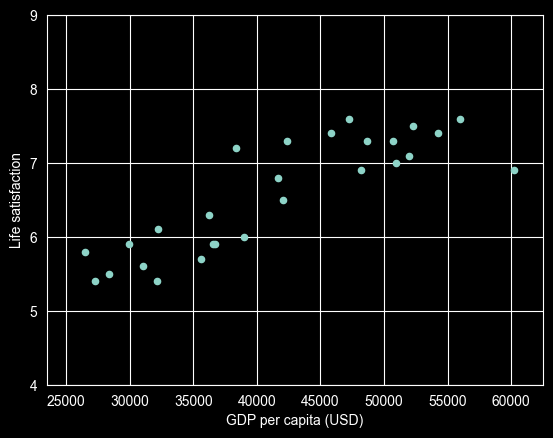

[[6.30165767]]


In [3]:
# 1-1 训练并运行一个预测模型
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# 下载并准备数据
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
print(lifesat)
X = lifesat[["GDP per capita (USD)"]].values
Y = lifesat[["Life satisfaction"]].values

# 数据可视化
lifesat.plot(kind='scatter', grid=True,
             x='GDP per capita (USD)', y='Life satisfaction')
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# 线性模型
model = LinearRegression()

# 训练模型
model.fit(X, Y)

# 预测一个国家的幸福指数
X_new = [[37655.2]]
print(model.predict(X_new)) # [[6.30165767]]

           Country  GDP per capita (USD)  Life satisfaction
0           Russia          26456.387938                5.8
1           Greece          27287.083401                5.4
2           Turkey          28384.987785                5.5
3           Latvia          29932.493910                5.9
4          Hungary          31007.768407                5.6
5         Portugal          32181.154537                5.4
6           Poland          32238.157259                6.1
7          Estonia          35638.421351                5.7
8            Spain          36215.447591                6.3
9         Slovenia          36547.738956                5.9
10       Lithuania          36732.034744                5.9
11          Israel          38341.307570                7.2
12           Italy          38992.148381                6.0
13  United Kingdom          41627.129269                6.8
14          France          42025.617373                6.5
15     New Zealand          42404.393738

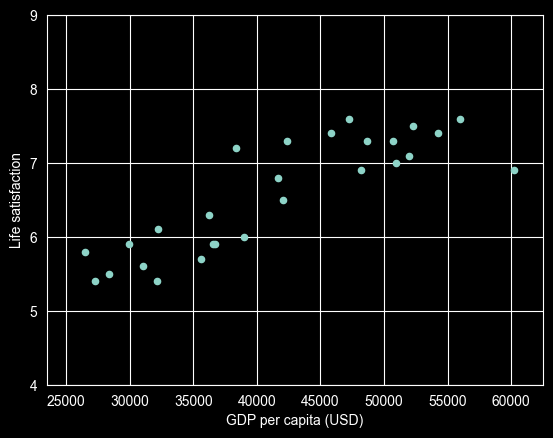

[[6.33333333]]


In [2]:
# 1-1 采用K近邻回归替换线性回归模型
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# 下载并准备数据
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
print(lifesat)
X = lifesat[["GDP per capita (USD)"]].values
Y = lifesat[["Life satisfaction"]].values

# 数据可视化
lifesat.plot(kind='scatter', grid=True,
             x='GDP per capita (USD)', y='Life satisfaction')
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# 线性模型
model = KNeighborsRegressor(n_neighbors=3)

# 训练模型
model.fit(X, Y)

# 预测一个国家的幸福指数
X_new = [[37655.2]]
print(model.predict(X_new)) # [[6.33333333]]


---

## Hands-On Machine Learning：19 个核心问题与答案（Q&A）

### Q1：什么是机器学习中的“学习”？

**A：**
机器学习是构建能够从数据中学习的系统。所谓“学习”，是指在给定某种性能度量标准的前提下，系统在某项任务上的表现不断提升。

---

### Q2：为什么要使用机器学习？

**A：**
机器学习适用于以下场景：

* 问题过于复杂，难以用明确算法描述
* 替代冗长且依赖人工调参的规则系统
* 构建能够适应环境变化的系统
* 帮助人类从大量数据中发现模式（如数据挖掘）

---

### Q3：什么是带标签的训练集？

**A：**
带标签的训练集是指：训练数据中，每个样本都包含其对应的期望输出结果，即**标签（label）**。

---

### Q4：最常见的监督学习任务有哪些？

**A：**
最常见的两类监督学习任务是：

* **回归（Regression）**
* **分类（Classification）**

---

### Q5：常见的无监督学习任务有哪些？

**A：**
常见的无监督学习任务包括：

* 聚类（Clustering）
* 可视化（Visualization）
* 降维（Dimensionality Reduction）
* 关联规则学习（Association Rule Learning）

---

### Q6：为什么机器人行走问题适合强化学习？

**A：**
因为机器人需要在未知环境中通过试错不断改进策略，这正是强化学习的典型应用场景。虽然可以将其形式化为监督或半监督学习问题，但并不自然。

---

### Q7：什么时候用聚类，什么时候用分类？

**A：**

* 如果事先不知道分组方式，使用**聚类（无监督学习）**
* 如果已知希望得到的类别，使用**分类（监督学习）**

---

### Q8：垃圾邮件检测属于哪类学习问题？

**A：**
垃圾邮件检测是一个典型的**监督学习问题**，模型使用大量带标签的邮件样本（垃圾/非垃圾）进行训练。

---

### Q9：在线学习与批量学习有什么区别？

**A：**

* **在线学习**：模型可以增量学习，逐步更新
* **批量学习**：模型一次性在整个数据集上训练
  在线学习更适合数据不断变化或数据规模极大的场景。

---

### Q10：什么是外存学习（Out-of-core Learning）？

**A：**
外存学习用于处理无法完全载入内存的大规模数据。算法将数据切分为小批量，并使用在线学习方式逐批训练。

---

### Q11：什么是基于实例的学习？

**A：**
基于实例的学习系统会“记住”训练数据，在预测时通过相似度度量找到最相近的样本，并据此进行预测。

---

### Q12：模型参数与超参数有什么区别？

**A：**

* **模型参数**：由学习算法从数据中学习得到（如线性模型的斜率）
* **超参数**：学习算法本身的参数（如正则化强度）

---

### Q13：什么是基于模型的学习？

**A：**
基于模型的学习通过最小化代价函数来寻找最优模型参数，使模型在新数据上具有良好的泛化能力。

---

### Q14：机器学习的主要挑战有哪些？

**A：**
主要挑战包括：

* 数据不足
* 数据质量差
* 数据分布不具代表性
* 特征信息不足
* 欠拟合
* 过拟合

---

### Q15：什么是过拟合？如何应对？

**A：**
当模型在训练集上表现很好，但在新数据上表现较差时，说明模型发生了过拟合。
解决方法包括：

* 增加数据量
* 简化模型
* 使用正则化
* 降低数据噪声

---

### Q16：测试集的作用是什么？

**A：**
测试集用于在模型部署前，估计其在未知新样本上的泛化误差。

---

### Q17：验证集的作用是什么？

**A：**
验证集用于比较不同模型和调节超参数，从而选择最优模型。

---

### Q18：什么是 Train-Dev 集？什么时候使用？

**A：**
当训练数据与验证/测试数据可能存在分布不一致时，引入 train-dev 集用于判断是过拟合还是数据分布不匹配。

---

### Q19：为什么不能用测试集调参？

**A：**
因为这样会导致模型对测试集过拟合，使评估结果过于乐观，最终上线模型的真实性能可能低于预期。

---
